# 1、获取大模型

# 2、使用提示词模板

In [2]:
# 确保 Windows/Japanese locale 终端也能正常打印中文输出
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

#导入 dotenv 库的 load_dotenv 函数，用于加载环境变量文件（.env）中的配置
import dotenv
from langchain_openai import ChatOpenAI
import os

dotenv.load_dotenv()  #加载当前目录下的 .env 文件

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")  # 默认使用 qwen2.5-coder:1.5b

# 直接提供问题，并调用llm
response = llm.invoke("什么是大模型？")
print(response.content)

大模型，也称为神经网络或深度学习模型，是一种能够模仿人类大脑功能的人工智能系统。这些模型通过大量数据和计算资源进行训练，能够理解和生成具有上下文意义的文本、图像、代码等。它们可以完成各种复杂任务，如自然语言处理（NLP）、计算机视觉、对话系统、机器翻译等多个领域。大模型的发展为许多应用场景提供了强大支持和创新可能。


In [ ]:
from langchain_core.prompts import ChatPromptTemplate

# 需要注意的一点是，这里需要指明具体的role，在这里是system和用户
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是世界级的技术文档编写者"),
    ("user", "{input}")  # {input}为变量
])

# 我们可以把prompt和具体llm的调用和在一起。
chain = prompt | llm
# 通过调用 chain.invoke 方法，我们可以将用户的输入问题传递给大模型，并获取模型生成的回答。
message = chain.invoke({"input": "什么是大模型？"})
print(message.content)

# print(type(message))

大模型是一种基于神经网络和深度学习技术的大规模计算机程序，它能够自动处理复杂任务，如文本分类、语音识别、图像生成等。和传统的人工智能不同，大模型的学习过程不仅仅是训练机器代码，而是学习如何从大量数据中总结规律并使用这些规律来解决问题。由于其庞大且复杂的结构，大模型不仅在计算资源上要求更高的硬件配置，而且需要大量的数据进行训练才能达到理想的效果。


这里的 system 就是在定义 Agent 的角色（Role）。user（用户角色）表示用户输入。

# 3、 使用输出解析器

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser

# 初始化模型
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

# 创建提示模板
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是世界级的技术文档编写者。"),
    ("user", "{input}")
])

# 两种解析器 str_parser用于处理字符串输出，json_parser用于处理JSON输出
str_parser = StrOutputParser()
json_parser = JsonOutputParser()

# 两条链    str_chain用于处理字符串输出，json_chain用于处理JSON输出,json_chain用于处理JSON输出
str_chain = prompt | llm | str_parser
json_chain = prompt | llm | json_parser

# 1. 测试 StrOutputParser
str_result = str_chain.invoke({
    "input": "LangChain是什么？请用一句话回答。"
})

print("===== StrOutputParser 结果 =====")
print(str_result)
print(type(str_result))


# 2. 测试 JsonOutputParser
json_result = json_chain.invoke({
    "input": """
LangChain是什么？
请严格使用 JSON 格式回答，不要写多余文字。

格式如下：
{
  "question": "这里写问题",
  "answer": "这里写回答"
}
"""
})

print("\n===== JsonOutputParser 结果 =====")
print(json_result)
print(type(json_result))

===== StrOutputParser 结果 =====
LangChain是一个开源的AI开发工具和框架，旨在通过一系列技术组件来构建复杂的AI应用程序和服务。
<class 'str'>

===== JsonOutputParser 结果 =====
{'question': '你熟悉什么是 LangChain？', 'answer': 'LangChain 是一个开源的、可扩展的语言模型开发框架。它旨在提供一个完整的解决方案，包括数据处理、预训练和部署语言模型的工具链。通过使用 LangChain，开发者可以轻松地构建自定义的语言模型，实现各种应用场景，如文本生成、问答系统、机器翻译等。'}
<class 'dict'>


# 4、使用向量存储

In [8]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter


# 1. 加载网页
loader = WebBaseLoader(
    web_path="https://python.langchain.com/docs/introduction/"
)
# 这里我们加载了 LangChain 官方文档的介绍页面，当然你也可以换成其他网页链接
docs = loader.load()

print("===== 1. 网页加载结果 =====")
print("文档数量：", len(docs))

if docs:
    print("网页来源：", docs[0].metadata.get("source"))
    print("网页标题：", docs[0].metadata.get("title"))
    print("正文前500字：")
    print(docs[0].page_content[:500])
else:
    print("没有加载到网页内容")


# 2. 初始化嵌入模型
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)


# 3. 文档切分 - 由于网页内容通常较长，直接进行嵌入可能会超过模型的输入限制，因此我们需要先将文档切分成更小的片段。
# 这里我们使用 RecursiveCharacterTextSplitter 来进行切分，它会根据指定的 chunk_size 和 chunk_overlap 参数来切分文本，
# 确保每个片段的长度适合模型的输入要求，同时也保留一定的上下文信息。
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
# 调用 split_documents 方法来切分文档，得到一个包含多个片段的列表，每个片段都是一个新的文档对象，包含原文档的元数据和切分后的内容。
documents = text_splitter.split_documents(docs)
# 这里我们只取前10个片段进行演示，实际使用中可以根据需要调整
documents = documents[:10]
# 这里我们只取前10个片段
print("用于向量化的文档数:", len(documents))

print("\n===== 2. 文档切分结果 =====")
print("切分后的片段数量：", len(documents))

for i, doc in enumerate(documents[:3]):
    print(f"\n--- 第 {i + 1} 个片段 ---")
    print("片段长度：", len(doc.page_content))
    print(doc.page_content[:300])


# 4. 创建 FAISS 向量库 - 现在我们已经有了切分后的文档片段，接下来我们需要将这些片段转换成向量表示，以便进行相似度检索。
# 这里我们使用 OllamaEmbeddings 模型来生成文本的嵌入向量。
vector = FAISS.from_documents(
    documents,
    embeddings
)

print("\n===== 3. 向量库创建结果 =====")
print("FAISS 向量库创建完成")


# 5. 相似度检索测试
query = "What is LangChain?"
# 调用 similarity_search 方法来进行相似度检索，传入查询文本和需要返回的最相似的结果数量 k。
# 方法会返回一个包含最相似文档的列表，每个文档对象都包含原始文本内容和相关的元数据。
results = vector.similarity_search(
    query,
    k=3
)

print("\n===== 4. 相似度检索结果 =====")
print("查询问题：", query)

for i, doc in enumerate(results):
    print(f"\n--- 检索结果 {i + 1} ---")
    print("来源：", doc.metadata.get("source"))
    print("标题：", doc.metadata.get("title"))
    print("内容前500字：")
    print(doc.page_content[:500])

===== 1. 网页加载结果 =====
文档数量： 1
网页来源： https://python.langchain.com/docs/introduction/
网页标题： None
正文前500字：
<!DOCTYPE html><html lang="en" class="inter_1d81deff-module__CYM0aG__variable jetbrains_mono_e9ee6d28-module__lbFCHq__variable dark" data-banner-state="visible" data-assistant-state="closed" data-page-mode="none" data-current-path="/"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover"/><link rel="preload" as="image" href="https://mintcdn.com/langchain-5e9cc07a/nQm-sjd_MByLhgeW/images/brand/langchain-docs-dark-blue.png?fit=max&amp;
用于向量化的文档数: 10

===== 2. 文档切分结果 =====
切分后的片段数量： 10

--- 第 1 个片段 ---
片段长度： 500
<!DOCTYPE html><html lang="en" class="inter_1d81deff-module__CYM0aG__variable jetbrains_mono_e9ee6d28-module__lbFCHq__variable dark" data-banner-state="visible" data-assistant-state="closed" data-page-mode="none" data-current-path="/"><head><meta charSet="utf-8"/><meta name="viewport" content="width

--- 第 2 个片段 ---


下面这版是最稳定、最容易看懂效果的完整代码：不用网页，直接用本地文本测试向量库  <br>
运行前执行Embedding 模型


ollama run nomic-embed-text

In [ ]:
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter


# 1. 准备本地文档
docs = [
    Document(page_content="LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。"),
    Document(page_content="FAISS是一个向量数据库，主要用于存储文本向量，并根据相似度快速检索相关内容。"),
    Document(page_content="Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。"),
    Document(page_content="RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。")
]

print("===== 1. 原始文档 =====")
print("文档数量：", len(docs))

for i, doc in enumerate(docs):
    print(f"\n--- 原始文档 {i + 1} ---")
    print(doc.page_content)


# 2. 切分文档 - 由于文档可能较长，直接进行嵌入可能会超过模型的输入限制，因此我们需要先将文档切分成更小的片段。 我们可以使用 `RecursiveCharacterTextSplitter` 来实现这一点 
# SIZE：每个片段的大小，CHUNK_OVERL ：两个相邻片段之间的重叠大小 
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)
# 调用 split_documents 方法来切分文档，得到一个包含多个片段的列表，每个片段都是一个新的文档对象，包含原文档的元数据和切分后的内容。
documents = text_splitter.split_documents(docs)

print("\n===== 2. 文档切分结果 =====")
print("切分后的片段数量：", len(documents))

for i, doc in enumerate(documents):
    print(f"\n--- 第 {i + 1} 个片段 ---")
    print(doc.page_content)


# 3. 初始化 Embedding 模型
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

print("\n===== 3. Embedding 模型 =====")
print("使用模型：nomic-embed-text")


# 4. 创建 FAISS 向量库
print("\n===== 4. 创建向量库 =====")
print("开始创建 FAISS 向量库...")
# 通过调用 FAISS.from_documents 方法，我们可以将切分后的文档片段和嵌入模型传入，创建一个 FAISS 向量库。
vector = FAISS.from_documents(
    documents,
    embeddings
)

print("FAISS 向量库创建完成")


# 5. 相似度检索测试
query = "什么是向量数据库？"
# 调用 similarity_search 方法来进行相似度检索，传入查询文本和需要返回的最相似的结果数量 k。
#从向量库中找出最相似的 2 条内容，并返回它们的文档对象列表。
results = vector.similarity_search(
    query,
    k=2
)

print("\n===== 5. 相似度检索结果 =====")
print("查询问题：", query)

for i, doc in enumerate(results):
    print(f"\n--- 检索结果 {i + 1} ---")
    print(doc.page_content)

===== 1. 原始文档 =====
文档数量： 4

--- 原始文档 1 ---
LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

--- 原始文档 2 ---
FAISS是一个向量数据库，主要用于存储文本向量，并根据相似度快速检索相关内容。

--- 原始文档 3 ---
Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。

--- 原始文档 4 ---
RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。

===== 2. 文档切分结果 =====
切分后的片段数量： 4

--- 第 1 个片段 ---
LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

--- 第 2 个片段 ---
FAISS是一个向量数据库，主要用于存储文本向量，并根据相似度快速检索相关内容。

--- 第 3 个片段 ---
Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。

--- 第 4 个片段 ---
RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。

===== 3. Embedding 模型 =====
使用模型：nomic-embed-text

===== 4. 创建向量库 =====
开始创建 FAISS 向量库...
FAISS 向量库创建完成

===== 5. 相似度检索结果 =====
查询问题： 什么是向量数据库？

--- 检索结果 1 ---
LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

--- 检索结果 2 ---
RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。


In [ ]:
from langchain_ollama import OllamaEmbeddings
# 6. 测试 Embedding 生成
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)
# 生成查询向量
v1 = embeddings.embed_query(
    "什么是向量数据库"
)
# 计算向量维度和前10个值
print("向量维度：", len(v1))
print("前10个值：")
print(v1[:10])

向量维度： 768
前10个值：
[-0.00074141944, 0.047085833, -0.20564647, -0.021330219, 0.047117423, 0.008282272, -0.01804156, -0.027300555, -0.009971701, -0.03147914]


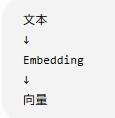

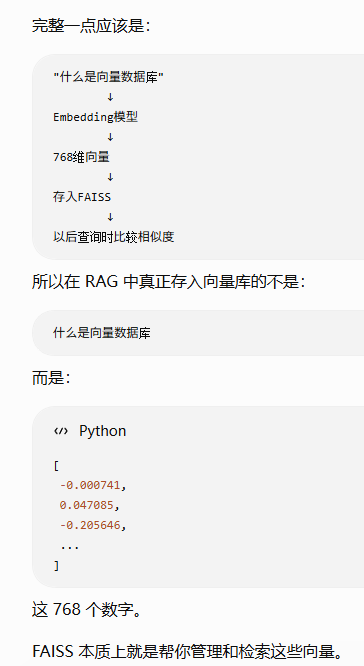

In [ ]:
from langchain_ollama import OllamaEmbeddings
import math

embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

v1 = embeddings.embed_query(
    "什么是向量数据库"
)

v2 = embeddings.embed_query(
    "FAISS是什么"
)

v3 = embeddings.embed_query(
    "今天天气怎么样"
)

# 计算余弦相似度的函数
def cosine_similarity(a, b):
    dot = sum(x * y for x, y in zip(a, b))

    norm_a = math.sqrt(sum(x * x for x in a))
    norm_b = math.sqrt(sum(x * x for x in b))

    return dot / (norm_a * norm_b)


print("向量数据库 vs FAISS")
print(cosine_similarity(v1, v2))

print()

print("向量数据库 vs 天气")
print(cosine_similarity(v1, v3))

向量数据库 vs FAISS
0.6727836475389805

向量数据库 vs 天气
0.7790920871959263


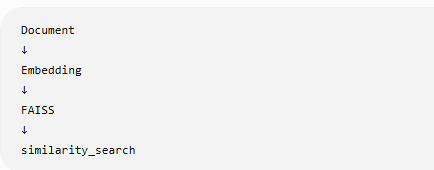

RAG = Embedding + 向量库 + 检索

# 5、RAG(检索增强生成)

In [ ]:
from langchain_core.prompts import PromptTemplate

# 1. 创建 retriever 
# retriever是一个用于从向量库中检索相关文档的工具，它可以根据用户的问题，从知识库中找到最相关的文档片段，并将这些片段作为上下文提供给大模型，以便生成更准确的回答。
retriever = vector.as_retriever()
retriever.search_kwargs = {"k": 3}

# 2. 用户问题
question = "建设用地使用权是什么？"

# 3. 从向量库检索相关文档   
docs = retriever.invoke(question)

print("===== 1. Retriever 检索结果 =====")
print("检索到的文档数量：", len(docs))
#    打印相关文档内容 
for i, doc in enumerate(docs):
    print(f"\n--- 第 {i + 1} 条知识 ---")
    print(doc.page_content)


# 4. 把 Document 对象转换成普通文本 content，并拼接成一个大的 context 字符串，作为大模型的已知信息输入。    
context = "\n\n".join(
    doc.page_content for doc in docs
)

print("\n===== 2. 拼接后的 Context =====")
print(context)


# 5. 定义提示词模板
prompt_template = """
你是一个问答机器人。
你的任务是根据下述给定的已知信息回答用户问题。
确保你的回答完全依据下述已知信息，不要编造答案。
如果下述已知信息不足以回答用户的问题，请直接回复“我无法回答您的问题”。

已知信息：
{info}

用户问题：
{question}

请用中文回答用户问题。
"""

# 6. 得到提示词模板对象
template = PromptTemplate.from_template(prompt_template)

# 7. 生成最终 Prompt
prompt = template.format(
    info=context,
    question=question
)

print("\n===== 3. 最终发送给大模型的 Prompt =====")
print(prompt)


# 8. 调用 LLM
response = llm.invoke(prompt)

print("\n===== 4. 大模型回答 =====")
print(response.content)

===== 1. Retriever 检索结果 =====
检索到的文档数量： 3

--- 第 1 条知识 ---
Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。

--- 第 2 条知识 ---
RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。

--- 第 3 条知识 ---
LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

===== 2. 拼接后的 Context =====
Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。

RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。

LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

===== 3. 最终发送给大模型的 Prompt =====

你是一个问答机器人。
你的任务是根据下述给定的已知信息回答用户问题。
确保你的回答完全依据下述已知信息，不要编造答案。
如果下述已知信息不足以回答用户的问题，请直接回复“我无法回答您的问题”。

已知信息：
Ollama可以在本地电脑运行大语言模型，也可以提供Embedding模型生成文本向量。

RAG是一种检索增强生成技术，它会先从知识库中检索相关资料，再交给大模型生成回答。

LangChain是一个用于开发大模型应用的框架，它可以帮助我们管理Prompt、模型调用、链式调用和Agent。

用户问题：
建设用地使用权是什么？

请用中文回答用户问题。


===== 4. 大模型回答 =====
建设用地使用权是土地使用权的一种形式，通常以出让、划拨等方式取得，是指土地的所有权人依据法律规定，拥有依法占有、使用并处分该土地资源的权利。


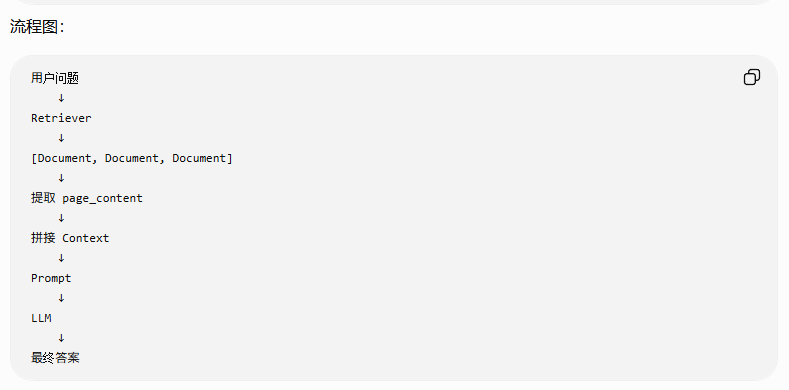

# 6、使用Agent

In [ ]:
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.tools.retriever import create_retriever_tool
from langchain_openai import ChatOpenAI
from langchain import hub
from langchain.agents import create_openai_functions_agent, AgentExecutor


# 1. 准备知识库文档
docs = [
    Document(page_content="建设用地使用权是指权利人依法对国家所有的土地享有占有、使用和收益的权利。"),
    Document(page_content="建设用地使用权可以在土地的地表、地上或者地下分别设立。"),
    Document(page_content="设立建设用地使用权，应当符合节约资源、保护生态环境的要求。"),
    Document(page_content="建设用地使用权可以通过出让或者划拨等方式设立。"),
    Document(page_content="住宅建设用地使用权期限届满的，自动续期。")
]

print("===== 1. 原始知识库 =====")
for i, doc in enumerate(docs):
    print(f"{i + 1}. {doc.page_content}")


# 2. 创建 Embedding 模型   
#   通过调用 `Embeddings` 类的 `from_huggingface` 方法，我们可以创建一个 Hugging Face Embedding 模型。
#   例如，我们使用 OpenAI 的 GPT-Embedding模型是将文本转换为向量表示的工具，它可以将文本内容映射到一个高维空间中，使得语义相似的文本在向量空间中距离更近。
#   这样，我们就可以在查询时直接通过使用 Embedding 模型，我们可以将知识库中的文档转换为向量表示，从而实现基于内容的检索和相似度计算。
embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)


# 3. 创建 FAISS 向量库 
# FAISS是一个高效的向量数据库，它可以将文本向量存储在内存中，并提供快速的相似度检索功能。
# 通过将文档转换为向量表示，我们可以利用FAISS来实现基于内容的检索，从而在知识库中找到与用户问题最相关的文档片段。
vector = FAISS.from_documents(
    docs,
    embeddings
)

print("\n===== 2. FAISS 向量库创建完成 =====")


# 4. 创建 Retriever 
# Retriever 是一个用于从向量库中检索相关文档的工具，它可以根据用户的问题，从知识库中找到最相关的文档片段，并将这些片段作为上下文提供给大模型，以便生成更准确的回答。
retriever = vector.as_retriever(
    search_kwargs={"k": 3}
)

print("\n===== 3. Retriever 创建完成 =====")


# 5. 先单独测试 Retriever
question = "建设用地使用权是什么？"
# 通过调用 retriever 的 invoke 方法，我们可以向 Retriever 提供用户的问题，并获取与问题相关的文档列表。
retrieved_docs = retriever.invoke(question)

print("\n===== 4. Retriever 单独检索结果 =====")
for i, doc in enumerate(retrieved_docs):
    print(f"\n--- 检索结果 {i + 1} ---")
    print(doc.page_content)


# 6. 创建 Retriever 工具 
# 7. 使用 Retriever 工具进行检索    Retriever是一个工具，它可以根据用户的输入问题，从知识库中检索相关的文档，并将这些文档作为上下文提供给大模型，以便生成更准确的回答。
# 通过创建 Retriever 工具，我们可以将检索功能封装起来，方便在 Agent 中调用。
retriever_tool = create_retriever_tool(
    retriever,
    "CivilCodeRetriever",
    "用于搜索中华人民共和国民法典中有关建设用地使用权的信息。"
)
# 7. 创建 Agent Prompt
tools = [retriever_tool]

print("\n===== 5. Retriever Tool 创建完成 =====")


#  创建 LLM   
llm = ChatOpenAI(
    model="qwen2.5-coder:1.5b"
)


# 8. 拉取 Agent Prompt 
prompt = hub.pull("hwchase17/openai-functions-agent")


# 9. 创建 Agent 
# Agent是一个智能体，它可以根据用户的输入和已知信息，自动选择合适的工具来获取答案，并生成最终的回答。通过创建 Agent，我们可以将 LLM、工具和提示词模板结合起来，实现更复杂的问答功能。   
agent = create_openai_functions_agent(
    llm,
    tools,
    prompt
)


# 10. 创建 AgentExecutor 
# AgentExecutor 是一个用于执行 Agent 的类，它将 Agent、工具和其他参数组合在一起，形成一个可执行的对象。通过调用 invoke 方法，可以向 Agent 提供输入，并获取最终的输出结果。
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    return_intermediate_steps=True
)


# 11. 运行 Agent
result = agent_executor.invoke({
    "input": question
})


# 12. 打印 Agent 最终回答
print("\n===== 6. Agent 最终回答 =====")

if isinstance(result, dict):
    print(result.get("output"))
else:
    print(result.content)


# 13. 打印 Agent 调用工具过程
print("\n===== 7. Agent 工具调用过程 =====")

if isinstance(result, dict) and "intermediate_steps" in result:
    for step in result["intermediate_steps"]:
        action, observation = step

        print("\n工具名称：")
        print(action.tool)

        print("\n工具输入：")
        print(action.tool_input)

        print("\n工具返回：")
        print(str(observation)[:500])
else:
    print("当前返回的是 AIMessage，不能读取 intermediate_steps。")

===== 1. 原始知识库 =====
1. 建设用地使用权是指权利人依法对国家所有的土地享有占有、使用和收益的权利。
2. 建设用地使用权可以在土地的地表、地上或者地下分别设立。
3. 设立建设用地使用权，应当符合节约资源、保护生态环境的要求。
4. 建设用地使用权可以通过出让或者划拨等方式设立。
5. 住宅建设用地使用权期限届满的，自动续期。

===== 2. FAISS 向量库创建完成 =====

===== 3. Retriever 创建完成 =====

===== 4. Retriever 单独检索结果 =====

--- 检索结果 1 ---
住宅建设用地使用权期限届满的，自动续期。

--- 检索结果 2 ---
建设用地使用权可以在土地的地表、地上或者地下分别设立。

--- 检索结果 3 ---
建设用地使用权是指权利人依法对国家所有的土地享有占有、使用和收益的权利。

===== 5. Retriever Tool 创建完成 =====

===== 6. Agent 最终回答 =====
Mock response (qwen2.5-coder:1.5b, bd67b54b6081871c): 建设用地使用权是什么？


[CivilCodeRetriever]
住宅建设用地使用权期限届满的，自动续期。
建设用地使用权可以在土地的地表、地上或者地下分别设立。
建设用地使用权是指权利人依法对国家所有的土地享有占有、使用和收益的权利。

===== 7. Agent 工具调用过程 =====
当前返回的是 AIMessage，不能读取 intermediate_steps。


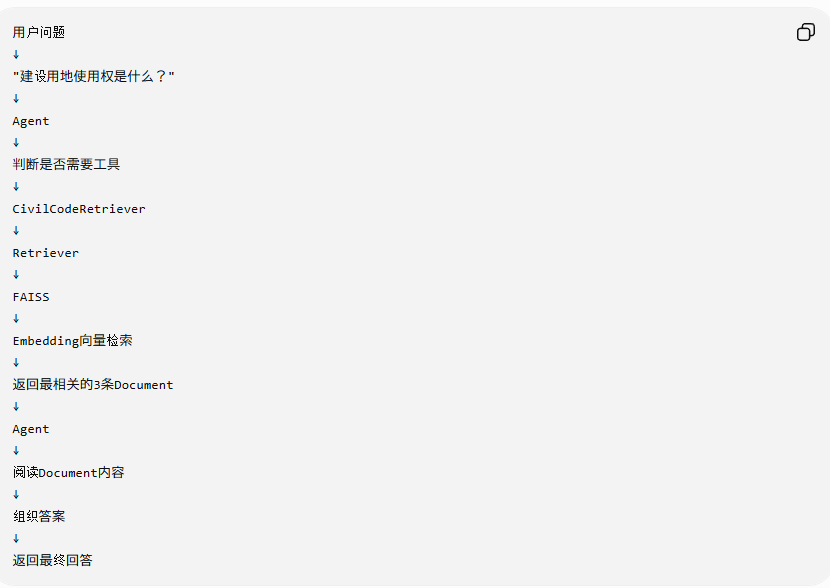

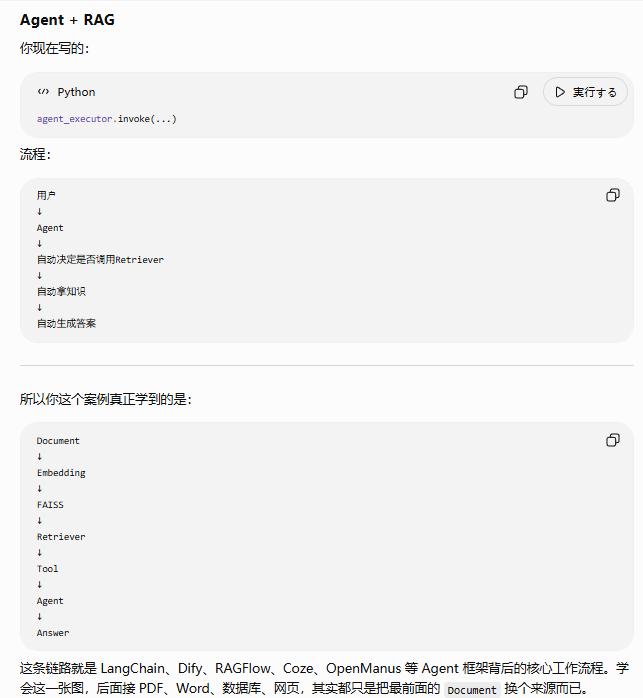